# P9 - Corrélation Bivariée
## Fonction générique pour établir la corrélation entre 2 variables

---

### 🎯 Objectif

Déterminer s'il existe un **lien statistique** entre 1 variable quantitative/qualititive et 1 variable quantitative/qualititive.

### Les corrélations possibles

| Type        | Test | Indicateur | Graphique | Exemple | 
|-------------|------|------------|-----------|----------|
| Quali/Quali | **Chi²** | χ², p-value | Heatmap / Barplot| Genre ↔ Catégories |
| Quanti/Quanti | **Pearson/Spearman** | R², p-value | Nuage de points | Âge ↔ Montant total |
| Quanti/Quali | **ANOVA** (ou KS) | η², F, p-value | Boxplot | Âge ↔ Catégories |



### 📚 Ce que vous allez apprendre

| Étape | Méthode | Outil |
|-------|---------|-------|
| Préparer | Agréger les données si nécessaire | `groupby()` |
| Visualiser | Réprésenter les données avec le type de graphique adapté | `plotly` / `seaborn` |
| Vérifier la normalité | Test de Shapiro-Wilk pour les donnés quanti | `scipy.stats.shapiro` |
| Tester | Utiliser le test statistique adapté aux données | `scipy.stats` |
| Interpréter | Coefficients adapté aux données | Grille de lecture |

---

### ⚠️ Choix du test selon la normalité des données quanti

| Condition | Test à utiliser | Caractéristiques |
|-----------|-----------------|------------------|
| Données normales | **Pearson** | Détecte les relations **linéaires** |
| Données non normales | **Spearman** | Détecte les relations **monotones** (pas forcément linéaires) |

```
Relation linéaire (Pearson)     Relation monotone (Spearman)
         •                              •    •
       •                              •   •
     •                              •  •
   •                              • •
 •                              ••
```

---

## 1. Configuration et chargement des données

In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Bibliothèques statistiques
from scipy import stats
from scipy.stats import shapiro, normaltest, pearsonr, spearmanr

# Configuration
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Bibliothèques chargées avec succès !")

✅ Bibliothèques chargées avec succès !


In [56]:
# Charger les données préparées
DATA_PATH = "../data/processed/"

df_source = pd.read_csv(DATA_PATH + "transactions_enrichies.csv",
                 dtype={'id_prod': 'object', 'session_id': 'object', 'client_id': 'object',
                        'price': 'float64', 'categ': 'object', 'sex': 'object', 'birth': 'int64', 'segment_client': 'object', 'age_client': 'int64'})

df_source['date'] = pd.to_datetime(df_source['date'])

print(f"✅ Données chargées : {len(df_source):,} transactions")
print(f"\nColonnes disponibles : {list(df_source.columns)}")
print(f"\nTypes de données :\n{df_source.dtypes}")


df_source.head(3)

✅ Données chargées : 687,534 transactions

Colonnes disponibles : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth', 'segment_client', 'age_client']

Types de données :
id_prod                   object
date              datetime64[ns]
session_id                object
client_id                 object
price                    float64
categ                     object
sex                       object
birth                      int64
segment_client            object
age_client                 int64
dtype: object


,id_prod,date,session_id,client_id,price,categ,sex,birth,segment_client,age_client
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,B2C,59
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,B2C,66
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,B2C,38


## 2. Préparation des données

### Sélection des clients B2C

In [58]:
# Utiliser uniquement les clients B2C
df = df_source[df_source['segment_client'] == 'B2C']
df["segment_client"].value_counts()


segment_client
B2C    640734
Name: count, dtype: int64

### Agrégation à la maille client

In [ ]:
# Agrégation des données pour les corrélations


## 3. Fonction de corrélation

### Etape 1 : définition de la fonction

In [22]:
def correlation_bivariee(df, var1, var2, seuil=0.05):
    """
    Calcule la corrélation entre deux variables et affiche les résultats.
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable.
        var2 (str): Le nom de la deuxième variable.
        seuil (float): Le seuil de significativité pour la corrélation.
        
    Returns:
        dict: Un dictionnaire contenant les résultats de la corrélation.
        
    """
    # Initialisation de la fonction
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION")
    print("=" * 70)

Test de la fonction :

In [23]:
correlation_bivariee(df=df, var1='sex', var2='age_client', seuil=0.05)

📊 ANALYSE DE CORRÉLATION


### Etape 2 : déterminer les types de données

In [39]:
def correlation_bivariee(df, var1, var2, seuil=0.05):
    """
    Calcule la corrélation entre deux variables et affiche les résultats.
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable.
        var2 (str): Le nom de la deuxième variable.
        seuil (float): Le seuil de significativité pour la corrélation.
        
    Returns:
        dict: Un dictionnaire contenant les résultats de la corrélation.
        
    """
    # Initialisation de la fonction
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION")
    print("=" * 70)
    
    # Identifier les types de variables
    type_var1 = df[var1].dtype
    type_var2 = df[var2].dtype
    
    # Correction du choix utilisateur si type_var1='quanti' et type_var2='quali' => convention pour rendre robuste le protocole de corrélation
    if (type_var1 in ['int64', 'float64']) and (type_var2 == 'object'):
        var1, var2 = var2, var1
        type_var1, type_var2 = type_var2, type_var1
    print("\n" + "-" * 70)
    print(f"🔍 Analyse de la corrélation entre '{var1}' (type : {type_var1}) et '{var2}' (type : {type_var2})")

Test de la fonction :

In [40]:
correlation_bivariee(df=df, var1='sex', var2='age_client', seuil=0.05)

📊 ANALYSE DE CORRÉLATION

----------------------------------------------------------------------
🔍 Analyse de la corrélation entre 'sex' (type : object) et 'age_client' (type : int64)


### Etape 3 : définir les modalités de l'évaluation statistique

In [43]:
def correlation_bivariee(df, var1, var2, seuil=0.05):
    """
    Calcule la corrélation entre deux variables et affiche les résultats.
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable.
        var2 (str): Le nom de la deuxième variable.
        seuil (float): Le seuil de significativité pour la corrélation.
        
    Returns:
        dict: Un dictionnaire contenant les résultats de la corrélation.
        
    """
    # Initialisation de la fonction
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION")
    print("=" * 70)
    
    # Identifier les types de variables
    type_var1 = df[var1].dtype
    type_var2 = df[var2].dtype
    
    # Correction du choix utilisateur si type_var1='quanti' et type_var2='quali' => convention pour rendre robuste le protocole de corrélation
    if (type_var1 in ['int64', 'float64']) and (type_var2 == 'object'):
        var1, var2 = var2, var1
        type_var1, type_var2 = type_var2, type_var1
    print("\n" + "-" * 70)
    print(f"🔍 Analyse de la corrélation entre '{var1}' (type : {type_var1}) et '{var2}' (type : {type_var2})")
    
    # Déterminer le test de corrélation approprié
    if type_var1 == 'object' and type_var2 == 'object':
        protocole_correlation = {
            'type_correlation': "quali-quali",
            'test_correlation': "Chi2",
            'graph_correlation': "heatmap"
        }
    elif (type_var1 in ['int64', 'float64']) and (type_var2 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quanti-quanti",
            'test_correlation': "Pearson/Spearman",
            'graph_correlation': "scatterplot (nuage de points)"
        }
    elif (type_var1 == 'object' and type_var2 in ['int64', 'float64']) or (type_var2 == 'object' and type_var1 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quali-quanti",
            'test_correlation': "ANOVA/Kruskal-Wallis",
            'graph_correlation': "boxplot"
        }
    else:
        protocole_correlation = None
    
    print("\n" + "-" * 70)
    if protocole_correlation:
        print(f"""✅ Protocole de corrélation identifié : 
            - Type{protocole_correlation['type_correlation']}
            - Test : {protocole_correlation['test_correlation']}
            - Graphique : {protocole_correlation['graph_correlation']}""")
    else:
        print("❌ Type de variables non pris en charge pour la corrélation.")

Test de la fonction :

In [44]:
correlation_bivariee(df=df, var2='sex', var1='age_client', seuil=0.05)

📊 ANALYSE DE CORRÉLATION

----------------------------------------------------------------------
🔍 Analyse de la corrélation entre 'sex' (type : object) et 'age_client' (type : int64)

----------------------------------------------------------------------
✅ Protocole de corrélation identifié : 
            - Typequali-quanti
            - Test : ANOVA/Kruskal-Wallis
            - Graphique : boxplot


### Etape 4 :  agréger les données si nécessaire

In [60]:
def correlation_bivariee(df, var1, var2, seuil=0.05):
    """
    Calcule la corrélation entre deux variables et affiche les résultats.
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable.
        var2 (str): Le nom de la deuxième variable.
        seuil (float): Le seuil de significativité pour la corrélation.
        
    Returns:
        dict: Un dictionnaire contenant les résultats de la corrélation.
        
    """
    # Initialisation de la fonction
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION")
    print("=" * 70)
    
    # Identifier les types de variables
    type_var1 = df[var1].dtype
    type_var2 = df[var2].dtype
    
    # Correction du choix utilisateur si type_var1='quanti' et type_var2='quali' => convention pour rendre robuste le protocole de corrélation
    if (type_var1 in ['int64', 'float64']) and (type_var2 == 'object'):
        var1, var2 = var2, var1
        type_var1, type_var2 = type_var2, type_var1
    print("\n" + "-" * 70)
    print(f"🔍 Analyse de la corrélation entre '{var1}' (type : {type_var1}) et '{var2}' (type : {type_var2})")
    
    # Déterminer le test de corrélation approprié
    if type_var1 == 'object' and type_var2 == 'object':
        protocole_correlation = {
            'type_correlation': "quali-quali",
            'test_correlation': "Chi2",
            'graph_correlation': "heatmap"
        }
    elif (type_var1 in ['int64', 'float64']) and (type_var2 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quanti-quanti",
            'test_correlation': "Pearson/Spearman",
            'graph_correlation': "scatterplot (nuage de points)"
        }
    elif (type_var1 == 'object' and type_var2 in ['int64', 'float64']) or (type_var2 == 'object' and type_var1 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quali-quanti",
            'test_correlation': "ANOVA/Kruskal-Wallis",
            'graph_correlation': "boxplot"
        }
    else:
        protocole_correlation = None
    
    print("\n" + "-" * 70)
    if protocole_correlation:
        print(f"""✅ Protocole de corrélation identifié : 
            - Type{protocole_correlation['type_correlation']}
            - Test : {protocole_correlation['test_correlation']}
            - Graphique : {protocole_correlation['graph_correlation']}""")
    else:
        print("❌ Type de variables non pris en charge pour la corrélation.")
        
    # Agrégation des données pour les graphiques et les tests
    print("\n" + "-" * 70)
    if protocole_correlation['type_correlation'] == "quali-quali":
        table = pd.crosstab(df[var1], df[var2], normalize='index')
        print(f"📊 Tableau de contingence :\n{table}")
    elif protocole_correlation['type_correlation'] == "quali-quanti":
        table = df.groupby(var1)[var2].agg(['mean', 'std', 'count', 'min', 'max']).reset_index()
        print(f"📊 Données agrégées pour {var1} & {var2} :\n{table}")
    elif protocole_correlation['type_correlation'] == "quanti-quanti":
        table = df[[var1, var2]].dropna()
        print(f"📊 Données pour le scatterplot :\n{table.head()}")

Test de la fonction :

In [61]:
correlation_bivariee(df=df, var2='sex', var1='age_client', seuil=0.05)

📊 ANALYSE DE CORRÉLATION

----------------------------------------------------------------------
🔍 Analyse de la corrélation entre 'sex' (type : object) et 'age_client' (type : int64)

----------------------------------------------------------------------
✅ Protocole de corrélation identifié : 
            - Typequali-quanti
            - Test : ANOVA/Kruskal-Wallis
            - Graphique : boxplot

----------------------------------------------------------------------
📊 Données agrégées pour sex & age_client :
  sex       mean        std   count  min  max
0   f  48.484602  14.025948  333494   22   97
1   m  47.907711  13.712861  307240   22   97


### Etape 5 : visualiser les données

In [ ]:
def correlation_bivariee(df, var1, var2, seuil=0.05):
    """
    Calcule la corrélation entre deux variables et affiche les résultats.
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable.
        var2 (str): Le nom de la deuxième variable.
        seuil (float): Le seuil de significativité pour la corrélation.
        
    Returns:
        dict: Un dictionnaire contenant les résultats de la corrélation.
        
    """
    # Initialisation de la fonction
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION")
    print("=" * 70)
    
    # Identifier les types de variables
    type_var1 = df[var1].dtype
    type_var2 = df[var2].dtype
    
    # Correction du choix utilisateur si type_var1='quanti' et type_var2='quali' => convention pour rendre robuste le protocole de corrélation
    if (type_var1 in ['int64', 'float64']) and (type_var2 == 'object'):
        var1, var2 = var2, var1
        type_var1, type_var2 = type_var2, type_var1
    print("\n" + "-" * 70)
    print(f"🔍 Analyse de la corrélation entre '{var1}' (type : {type_var1}) et '{var2}' (type : {type_var2})")
    
    # Déterminer le test de corrélation approprié
    if type_var1 == 'object' and type_var2 == 'object':
        protocole_correlation = {
            'type_correlation': "quali-quali",
            'test_correlation': "Chi2",
            'graph_correlation': "heatmap"
        }
    elif (type_var1 in ['int64', 'float64']) and (type_var2 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quanti-quanti",
            'test_correlation': "Pearson/Spearman",
            'graph_correlation': "scatterplot (nuage de points)"
        }
    elif (type_var1 == 'object' and type_var2 in ['int64', 'float64']) or (type_var2 == 'object' and type_var1 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quali-quanti",
            'test_correlation': "ANOVA/Kruskal-Wallis",
            'graph_correlation': "boxplot"
        }
    else:
        protocole_correlation = None
    
    print("\n" + "-" * 70)
    if protocole_correlation:
        print(f"""✅ Protocole de corrélation identifié : 
            - Type{protocole_correlation['type_correlation']}
            - Test : {protocole_correlation['test_correlation']}
            - Graphique : {protocole_correlation['graph_correlation']}""")
    else:
        print("❌ Type de variables non pris en charge pour la corrélation.")

    # Agrégation des données pour les graphiques et les tests
    print("\n" + "-" * 70)
    if protocole_correlation['type_correlation'] == "quali-quali":
        table = pd.crosstab(df[var1], df[var2])
        print(f"📊 Tableau de contingence :\n{table}")
    elif protocole_correlation['type_correlation'] == "quali-quanti":
        table = df.groupby(var1)[var2].agg(['mean', 'std', 'count', 'min', 'max']).reset_index()
        print(f"📊 Données agrégées pour {var1} & {var2} :\n{table}")
    elif protocole_correlation['type_correlation'] == "quanti-quanti":
        table = df[[var1, var2]].dropna()
        print(f"📊 Données pour le scatterplot :\n{table.head()}")
        
    # Visualiser les données selon le type de corrélation
    print("\n" + "-" * 70)
    if protocole_correlation['type_correlation'] == "quali-quali":
        plt.figure(figsize=(8, 6))
        sns.heatmap(table, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Heatmap de la corrélation entre '{var1}' et '{var2}'")
        plt.show()
    elif protocole_correlation['type_correlation'] == "quali-quanti":
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=var1, y=var2, data=df)
        plt.title(f"Boxplot de '{var2}' en fonction de '{var1}'")
        plt.show()
    elif protocole_correlation['type_correlation'] == "quanti-quanti":
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=var1, y=var2, data=df)
        plt.title(f"Scatterplot de '{var1}' vs '{var2}'")
        plt.show()

Test de la fonction :

📊 ANALYSE DE CORRÉLATION

----------------------------------------------------------------------
🔍 Analyse de la corrélation entre 'age_client' (type : int64) et 'price' (type : float64)

----------------------------------------------------------------------
✅ Protocole de corrélation identifié : 
            - Typequanti-quanti
            - Test : Pearson/Spearman
            - Graphique : scatterplot (nuage de points)

----------------------------------------------------------------------
📊 Données pour le scatterplot :
   age_client  price
0          59  11.99
1          66  19.37
2          38   4.50
3          37   6.55
4          70  16.49

----------------------------------------------------------------------


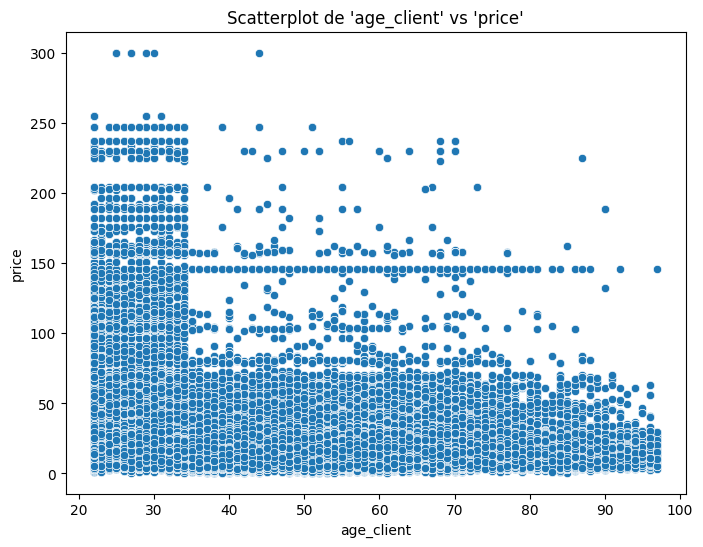

In [64]:
correlation_bivariee(df=df, var1='age_client', var2='price', seuil=0.05)

In [ ]:
def correlation_bivariee(df, var1, var2, seuil=0.05):
    """
    Calcule la corrélation entre deux variables et affiche les résultats.
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable.
        var2 (str): Le nom de la deuxième variable.
        seuil (float): Le seuil de significativité pour la corrélation.
        
    Returns:
        dict: Un dictionnaire contenant les résultats de la corrélation.
        
    """
    # Initialisation de la fonction
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION")
    print("=" * 70)
    
    # Identifier les types de variables
    type_var1 = df[var1].dtype
    type_var2 = df[var2].dtype
    print(f"🔍 Analyse de la corrélation entre '{var1}' (type : {type_var1}) et '{var2}' (type : {type_var2})")
    
    # Déterminer le test de corrélation approprié
    if type_var1 == 'object' and type_var2 == 'object':
        protocole_correlation = {
            'type_correlation': "quali-quali",
            'test_correlation': "Chi2",
            'graph_correlation': "heatmap"
        }
    elif (type_var1 in ['int64', 'float64']) and (type_var2 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quanti-quanti",
            'test_correlation': "Pearson/Spearman",
            'graph_correlation': "scatterplot (nuage de points)"
        }
    elif (type_var1 == 'object' and type_var2 in ['int64', 'float64']) or (type_var2 == 'object' and type_var1 in ['int64', 'float64']):
        protocole_correlation = {
            'type_correlation': "quali-quanti",
            'test_correlation': "ANOVA/Kruskal-Wallis",
            'graph_correlation': "boxplot"
        }
    else:
        protocole_correlation = None
    if protocole_correlation:
        print(f"""✅ Protocole de corrélation identifié : 
            - Type{protocole_correlation['type_correlation']}
            - Test : {protocole_correlation['test_correlation']}
            - Graphique : {protocole_correlation['graph_correlation']}""")
    else:
        print("❌ Type de variables non pris en charge pour la corrélation.")
        
    # Agrégation des données pour les graphiques et les tests
    if protocole_correlation['type_correlation'] == "quali-quali":
        contingency_table = pd.crosstab(df[var1], df[var2])
        print(f"\n📊 Tableau de contingence :\n{contingency_table}")
    elif protocole_correlation['type_correlation'] == "quali-quanti":
        aggregated_data = df.groupby(var1)[var2].agg(['mean', 'std', 'count', 'min', 'max']).reset_index()
        print(f"\n📊 Données agrégées pour {var1} :\n{aggregated_data}")
    
    
    """
    # Calculer les coefficients de corrélation
    pearson_corr, pearson_p = pearsonr(df[var1], df[var2])
    spearman_corr, spearman_p = spearmanr(df[var1], df[var2])
    
    # Afficher les résultats
    print(f"Corrélation de Pearson entre {var1} et {var2} : {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
    print(f"Corrélation de Spearman entre {var1} et {var2} : {spearman_corr:.4f} (p-value: {spearman_p:.4f})")
    
    # Interprétation
    if pearson_p < seuil:
        print(f"✅ La corrélation de Pearson est significative au seuil de {seuil}.")
    else:
        print(f"❌ La corrélation de Pearson n'est pas significative au seuil de {seuil}.")
        
    if spearman_p < seuil:
        print(f"✅ La corrélation de Spearman est significative au seuil de {seuil}.")
    else:
        print(f"❌ La corrélation de Spearman n'est pas significative au seuil de {seuil}.")
    
    return {
        'pearson_corr': pearson_corr,
        'pearson_p': pearson_p,
        'spearman_corr': spearman_corr,
        'spearman_p': spearman_p
    }
    """

---

## 2. Préparation des données

### 📚 Problème

Nos données sont au niveau **transaction** (une ligne = un achat).

Pour analyser la corrélation Âge ↔ Montant total, nous devons **agréger par client** :
- Chaque client a **un seul âge**
- Chaque client a **un montant total** (somme de ses achats)

In [17]:
print(f"\nÂge min : {df['age_client'].min()} ans")
print(f"Âge max : {df['age_client'].max()} ans")
print(f"Âge moyen : {df['age_client'].mean():.1f} ans")


Âge min : 22 ans
Âge max : 97 ans
Âge moyen : 48.2 ans


In [18]:
# Agréger par client
clients = df.groupby('client_id').agg({
    'age_client': 'first',           # L'âge est le même pour toutes les transactions d'un client
    'sex': 'first',           # Idem pour le sexe
    'price': 'sum',           # Montant total des achats
    'id_prod': 'count'        # Nombre de transactions
}).reset_index()

# Renommer les colonnes
clients.columns = ['client_id', 'age', 'sex', 'montant_total', 'nb_transactions']

print(f"✅ Données agrégées : {len(clients):,} clients")
display(clients.head())

✅ Données agrégées : 8,596 clients


,client_id,age,sex,montant_total,nb_transactions
0,c_1,71,m,629.02,43
1,c_10,70,m,1353.60,58
2,c_100,34,m,254.85,8
3,c_1000,60,f,2291.88,126
4,c_1001,44,m,1823.85,103


In [19]:
# Statistiques descriptives
print("📊 STATISTIQUES DESCRIPTIVES")
print("=" * 50)
display(clients[['age', 'montant_total']].describe().round(2))

📊 STATISTIQUES DESCRIPTIVES


,age,montant_total
count,8596.00,8596.00
mean,47.74,1296.34
std,16.91,958.40
min,22.00,6.31
25%,34.00,562.64
50%,47.00,1045.58
75%,60.00,1796.02
max,97.00,5285.82


---

## 3. Visualisation : Nuage de points

Avant tout test statistique, **visualisons** la relation entre les deux variables.

In [20]:
# Nuage de points avec Plotly
fig = px.scatter(
    clients,
    x='age',
    y='montant_total',
    title='Relation entre Âge et Montant total des achats',
    labels={'age': 'Âge (années)', 'montant_total': 'Montant total (€)'},
    opacity=0.6,
    trendline='ols'  # Ajouter une droite de régression
)

fig.update_layout(
    template='plotly_white',
    height=500
)

fig.show()

In [21]:
# Version avec coloration par sexe
fig = px.scatter(
    clients,
    x='age',
    y='montant_total',
    color='sex',
    title='Relation Âge ↔ Montant total (par genre)',
    labels={'age': 'Âge (années)', 'montant_total': 'Montant total (€)', 'sex': 'Genre'},
    opacity=0.6,
    color_discrete_map={'f': '#E91E63', 'm': '#2196F3'}
)

fig.update_layout(template='plotly_white', height=500)
fig.show()

In [22]:
# Nuage de points avec distributions marginales (jointplot)
fig = px.scatter(
    clients,
    x='age',
    y='montant_total',
    marginal_x='histogram',
    marginal_y='histogram',
    title='Distribution conjointe : Âge et Montant total',
    labels={'age': 'Âge (années)', 'montant_total': 'Montant total (€)'},
    opacity=0.5
)

fig.update_layout(template='plotly_white', height=600)
fig.show()

### 🤔 Première observation

En regardant le nuage de points :
- Y a-t-il une **tendance** visible (croissante, décroissante) ?
- Les points forment-ils un **nuage serré** autour d'une droite ou sont-ils **dispersés** ?
- Y a-t-il des **points aberrants** (très éloignés des autres) ?

---

## 4. Test de normalité

### 📚 Pourquoi tester la normalité ?

Le test de **Pearson** suppose que les variables suivent une **distribution normale** (en forme de cloche).

Si ce n'est pas le cas, on utilise le test de **Spearman** qui n'a pas cette exigence.

### Tests disponibles

| Test | Usage | Taille recommandée |
|------|-------|--------------------|
| **Shapiro-Wilk** | Le plus puissant | n < 5000 |
| **D'Agostino-Pearson** | Alternative | n > 20 |
| **Kolmogorov-Smirnov** | Grands échantillons | n > 50 |

### 4.1 Visualisation des distributions

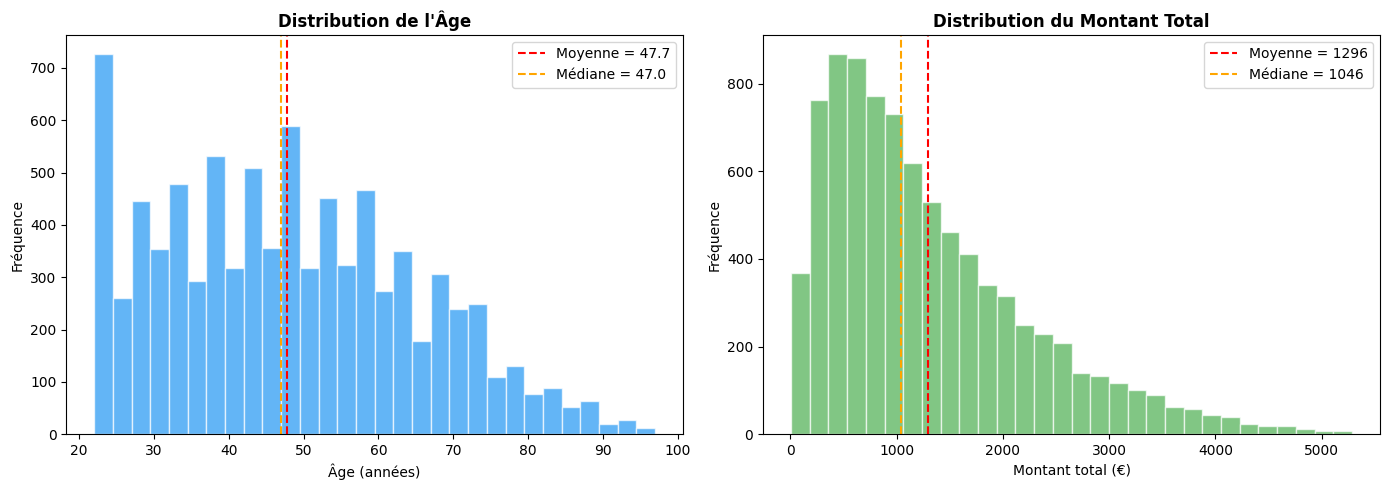

In [23]:
# Histogrammes des deux variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de l'âge
axes[0].hist(clients['age'], bins=30, edgecolor='white', color='#2196F3', alpha=0.7)
axes[0].axvline(clients['age'].mean(), color='red', linestyle='--', label=f"Moyenne = {clients['age'].mean():.1f}")
axes[0].axvline(clients['age'].median(), color='orange', linestyle='--', label=f"Médiane = {clients['age'].median():.1f}")
axes[0].set_title('Distribution de l\'Âge', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Âge (années)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Distribution du montant total
axes[1].hist(clients['montant_total'], bins=30, edgecolor='white', color='#4CAF50', alpha=0.7)
axes[1].axvline(clients['montant_total'].mean(), color='red', linestyle='--', label=f"Moyenne = {clients['montant_total'].mean():.0f}")
axes[1].axvline(clients['montant_total'].median(), color='orange', linestyle='--', label=f"Médiane = {clients['montant_total'].median():.0f}")
axes[1].set_title('Distribution du Montant Total', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Montant total (€)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

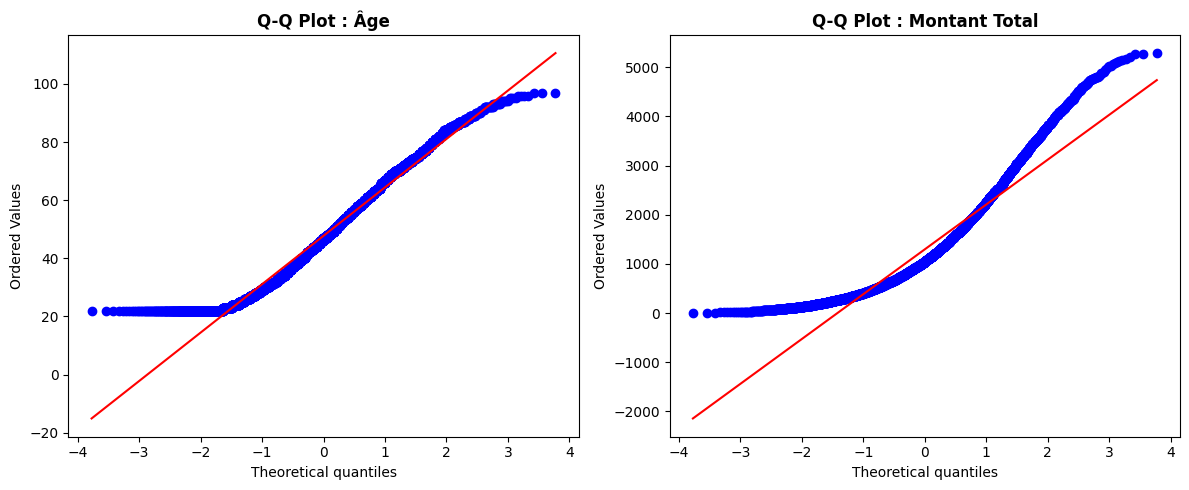

In [24]:
# Q-Q plots (comparaison avec une distribution normale théorique)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot Âge
stats.probplot(clients['age'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot : Âge', fontsize=12, fontweight='bold')

# Q-Q plot Montant total
stats.probplot(clients['montant_total'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot : Montant Total', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 📖 Comment lire un Q-Q Plot ?

| Observation | Interprétation |
|-------------|----------------|
| Points **alignés** sur la diagonale | Distribution normale ✅ |
| Points **en S** | Queues plus lourdes que la normale |
| Points **courbés vers le haut** à droite | Asymétrie à droite (queue longue) |
| Points **courbés vers le bas** à gauche | Asymétrie à gauche |

### 4.2 Test de Shapiro-Wilk

In [25]:
# Test de Shapiro-Wilk
# ⚠️ Limité à 5000 observations - on prend un échantillon si nécessaire

def test_normalite(data, nom_variable, n_max=5000):
    """
    Effectue un test de normalité (Shapiro-Wilk).
    
    Paramètres:
    -----------
    data : array-like, les données à tester
    nom_variable : str, nom de la variable (pour l'affichage)
    n_max : int, taille max pour Shapiro (défaut 5000)
    """
    
    print(f"\n🔍 TEST DE NORMALITÉ : {nom_variable}")
    print("-" * 50)
    
    # Nettoyer les données
    data_clean = pd.Series(data).dropna()
    n = len(data_clean)
    
    print(f"   Nombre d'observations : {n:,}")
    
    # Échantillonner si trop grand pour Shapiro
    if n > n_max:
        print(f"   ⚠️ Échantillonnage à {n_max} observations pour Shapiro-Wilk")
        data_test = data_clean.sample(n=n_max, random_state=42)
    else:
        data_test = data_clean
    
    # Test de Shapiro-Wilk
    stat_shapiro, p_shapiro = shapiro(data_test)
    
    print(f"\n   📊 Test de Shapiro-Wilk :")
    print(f"      Statistique W = {stat_shapiro:.4f}")
    print(f"      p-value = {p_shapiro:.4f}")
    
    # Interprétation
    seuil = 0.05
    if p_shapiro < seuil:
        print(f"\n   ❌ p-value < {seuil} → Distribution NON NORMALE")
        normale = False
    else:
        print(f"\n   ✅ p-value ≥ {seuil} → Distribution NORMALE (ou proche)")
        normale = True
    
    # Indicateurs supplémentaires
    skewness = data_clean.skew()
    kurtosis = data_clean.kurtosis()
    
    print(f"\n   📈 Indicateurs de forme :")
    print(f"      Asymétrie (skewness) = {skewness:.2f}", end="")
    if abs(skewness) < 0.5:
        print(" → Symétrique ✅")
    elif skewness > 0:
        print(" → Asymétrie droite (queue longue à droite)")
    else:
        print(" → Asymétrie gauche (queue longue à gauche)")
    
    print(f"      Aplatissement (kurtosis) = {kurtosis:.2f}", end="")
    if abs(kurtosis) < 1:
        print(" → Proche de la normale ✅")
    elif kurtosis > 0:
        print(" → Queues lourdes (plus de valeurs extrêmes)")
    else:
        print(" → Queues légères (moins de valeurs extrêmes)")
    
    return normale, p_shapiro

In [26]:
# Tester la normalité des deux variables
print("=" * 60)
print("📊 TESTS DE NORMALITÉ")
print("=" * 60)

normale_age, p_age = test_normalite(clients['age'], 'Âge')
normale_montant, p_montant = test_normalite(clients['montant_total'], 'Montant total')

📊 TESTS DE NORMALITÉ

🔍 TEST DE NORMALITÉ : Âge
--------------------------------------------------
   Nombre d'observations : 8,596
   ⚠️ Échantillonnage à 5000 observations pour Shapiro-Wilk

   📊 Test de Shapiro-Wilk :
      Statistique W = 0.9700
      p-value = 0.0000

   ❌ p-value < 0.05 → Distribution NON NORMALE

   📈 Indicateurs de forme :
      Asymétrie (skewness) = 0.36 → Symétrique ✅
      Aplatissement (kurtosis) = -0.63 → Proche de la normale ✅

🔍 TEST DE NORMALITÉ : Montant total
--------------------------------------------------
   Nombre d'observations : 8,596
   ⚠️ Échantillonnage à 5000 observations pour Shapiro-Wilk

   📊 Test de Shapiro-Wilk :
      Statistique W = 0.9061
      p-value = 0.0000

   ❌ p-value < 0.05 → Distribution NON NORMALE

   📈 Indicateurs de forme :
      Asymétrie (skewness) = 1.16 → Asymétrie droite (queue longue à droite)
      Aplatissement (kurtosis) = 1.09 → Queues lourdes (plus de valeurs extrêmes)


In [27]:
# Synthèse et choix du test
print("\n" + "=" * 60)
print("📋 SYNTHÈSE : CHOIX DU TEST DE CORRÉLATION")
print("=" * 60)

print(f"\n   Âge        : {'Normale ✅' if normale_age else 'Non normale ❌'}")
print(f"   Montant    : {'Normale ✅' if normale_montant else 'Non normale ❌'}")

if normale_age and normale_montant:
    test_choisi = 'pearson'
    print("\n   → Les deux variables sont normales")
    print("   → Test recommandé : PEARSON")
else:
    test_choisi = 'spearman'
    print("\n   → Au moins une variable n'est pas normale")
    print("   → Test recommandé : SPEARMAN")

print("\n" + "=" * 60)


📋 SYNTHÈSE : CHOIX DU TEST DE CORRÉLATION

   Âge        : Non normale ❌
   Montant    : Non normale ❌

   → Au moins une variable n'est pas normale
   → Test recommandé : SPEARMAN



---

## 5. Tests de corrélation

### 📚 Les deux tests

| Test | Ce qu'il mesure | Coefficient | Condition |
|------|-----------------|-------------|----------|
| **Pearson** | Corrélation **linéaire** | r | Normalité |
| **Spearman** | Corrélation **monotone** | ρ (rho) | Aucune |

### Interprétation du coefficient

| Valeur | Interprétation |
|--------|----------------|
| r = +1 | Corrélation positive parfaite |
| r > +0.7 | Corrélation positive forte |
| r = +0.3 à +0.7 | Corrélation positive modérée |
| r = 0 à +0.3 | Corrélation positive faible |
| r = 0 | Aucune corrélation |
| r < 0 | Corrélation négative (même logique) |

### 5.1 Test de Pearson

In [29]:
# Test de Pearson
r_pearson, p_pearson = pearsonr(clients['age'], clients['montant_total'])

print("=" * 60)
print("📊 TEST DE PEARSON (corrélation linéaire)")
print("=" * 60)
print(f"\n   Coefficient r = {r_pearson:.4f}")
print(f"   p-value = {p_pearson:.4f}")
print(f"   R² = {r_pearson**2:.4f} ({r_pearson**2*100:.1f}% de variance expliquée)")

📊 TEST DE PEARSON (corrélation linéaire)

   Coefficient r = -0.1876
   p-value = 0.0000
   R² = 0.0352 (3.5% de variance expliquée)


### 5.2 Test de Spearman

In [28]:
# Test de Spearman
rho_spearman, p_spearman = spearmanr(clients['age'], clients['montant_total'])

print("=" * 60)
print("📊 TEST DE SPEARMAN (corrélation monotone)")
print("=" * 60)
print(f"\n   Coefficient ρ (rho) = {rho_spearman:.4f}")
print(f"   p-value = {p_spearman:.4f}")

📊 TEST DE SPEARMAN (corrélation monotone)

   Coefficient ρ (rho) = -0.1845
   p-value = 0.0000


### 5.3 Comparaison des deux tests

In [30]:
# Tableau comparatif
print("\n" + "=" * 60)
print("📋 COMPARAISON DES TESTS")
print("=" * 60)

comparaison = pd.DataFrame({
    'Test': ['Pearson', 'Spearman'],
    'Coefficient': [r_pearson, rho_spearman],
    'p-value': [p_pearson, p_spearman],
    'Significatif (α=0.05)': ['Oui' if p_pearson < 0.05 else 'Non', 
                              'Oui' if p_spearman < 0.05 else 'Non']
})

display(comparaison)

# Interprétation
print(f"\n💡 Le test recommandé selon la normalité : {test_choisi.upper()}")


📋 COMPARAISON DES TESTS


,Test,Coefficient,p-value,Significatif (α=0.05)
0,Pearson,-0.187567,6.663512e-69,Oui
1,Spearman,-0.184538,1.021291e-66,Oui



💡 Le test recommandé selon la normalité : SPEARMAN


---

## 6. Interprétation complète

In [31]:
# Choisir le bon test selon la normalité
if test_choisi == 'pearson':
    coef = r_pearson
    p_value = p_pearson
    nom_test = 'Pearson'
    nom_coef = 'r'
else:
    coef = rho_spearman
    p_value = p_spearman
    nom_test = 'Spearman'
    nom_coef = 'ρ'

print("=" * 70)
print("📊 CONCLUSION FINALE")
print("=" * 70)

# 1. Significativité
seuil = 0.05
print(f"\n1️⃣  SIGNIFICATIVITÉ")
print(f"    Test utilisé : {nom_test}")
print(f"    p-value = {p_value:.4f}")

if p_value < seuil:
    print(f"    ✅ p-value < {seuil} → Corrélation SIGNIFICATIVE")
    significatif = True
else:
    print(f"    ❌ p-value ≥ {seuil} → Corrélation NON significative")
    significatif = False

# 2. Force et direction
print(f"\n2️⃣  FORCE ET DIRECTION")
print(f"    Coefficient {nom_coef} = {coef:.4f}")

# Direction
if coef > 0:
    direction = "POSITIVE"
    interpretation_dir = "Plus l'âge augmente, plus le montant tend à augmenter"
elif coef < 0:
    direction = "NÉGATIVE"
    interpretation_dir = "Plus l'âge augmente, plus le montant tend à diminuer"
else:
    direction = "NULLE"
    interpretation_dir = "Pas de relation entre l'âge et le montant"

# Force
abs_coef = abs(coef)
if abs_coef < 0.1:
    force = "NÉGLIGEABLE"
    symbole = "⚪"
elif abs_coef < 0.3:
    force = "FAIBLE"
    symbole = "🟡"
elif abs_coef < 0.5:
    force = "MODÉRÉE"
    symbole = "🟠"
elif abs_coef < 0.7:
    force = "FORTE"
    symbole = "🟢"
else:
    force = "TRÈS FORTE"
    symbole = "🟢🟢"

print(f"    Direction : {direction}")
print(f"    Force : {symbole} {force}")

# 3. Interprétation métier
print(f"\n3️⃣  INTERPRÉTATION MÉTIER")
if significatif:
    print(f"    {interpretation_dir}")
    print(f"    Cette relation est statistiquement significative (p < {seuil}).")
    if force in ['NÉGLIGEABLE', 'FAIBLE']:
        print(f"    ⚠️ Cependant, la force de cette relation est {force.lower()}.")
        print(f"    En pratique, l'âge explique peu le montant des achats.")
else:
    print(f"    Aucune relation significative entre l'âge et le montant total.")
    print(f"    L'âge n'est pas un facteur prédictif du montant des achats.")

print("\n" + "=" * 70)

📊 CONCLUSION FINALE

1️⃣  SIGNIFICATIVITÉ
    Test utilisé : Spearman
    p-value = 0.0000
    ✅ p-value < 0.05 → Corrélation SIGNIFICATIVE

2️⃣  FORCE ET DIRECTION
    Coefficient ρ = -0.1845
    Direction : NÉGATIVE
    Force : 🟡 FAIBLE

3️⃣  INTERPRÉTATION MÉTIER
    Plus l'âge augmente, plus le montant tend à diminuer
    Cette relation est statistiquement significative (p < 0.05).
    ⚠️ Cependant, la force de cette relation est faible.
    En pratique, l'âge explique peu le montant des achats.



---

## 7. Visualisation finale

In [32]:
# Graphique final avec annotations
fig = px.scatter(
    clients,
    x='age',
    y='montant_total',
    trendline='ols',
    title=f'Corrélation Âge ↔ Montant total ({nom_test}: {nom_coef}={coef:.3f}, p={p_value:.4f})',
    labels={'age': 'Âge (années)', 'montant_total': 'Montant total (€)'},
    opacity=0.5
)

# Ajouter une annotation avec le résultat
resultat_texte = f"{'✅ Significatif' if significatif else '❌ Non significatif'}<br>Force: {force}"

fig.add_annotation(
    x=0.02, y=0.98,
    xref='paper', yref='paper',
    text=resultat_texte,
    showarrow=False,
    font=dict(size=14),
    bgcolor='white',
    bordercolor='black',
    borderwidth=1
)

fig.update_layout(template='plotly_white', height=500)
fig.show()

---

## 8. Fonction récapitulative 🎁

In [33]:
def analyser_correlation_quanti_quanti(df, var1, var2, seuil=0.05):
    """
    Analyse complète de corrélation entre deux variables quantitatives.
    Inclut test de normalité et choix automatique Pearson/Spearman.
    
    Paramètres:
    -----------
    df : DataFrame contenant les données
    var1 : nom de la première variable
    var2 : nom de la deuxième variable
    seuil : seuil de significativité (défaut : 0.05)
    
    Retourne:
    ---------
    dict avec tous les résultats
    """
    
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION : {var1} ↔ {var2}")
    print("=" * 70)
    
    # Données
    x = df[var1].dropna()
    y = df[var2].dropna()
    
    # Aligner les données (même index)
    data = df[[var1, var2]].dropna()
    x = data[var1]
    y = data[var2]
    
    print(f"\n   Observations valides : {len(data):,}")
    
    # 1. Tests de normalité
    print("\n1️⃣  TESTS DE NORMALITÉ (Shapiro-Wilk)")
    print("-" * 50)
    
    # Échantillonner si > 5000
    n_test = min(5000, len(x))
    if len(x) > 5000:
        print(f"   ⚠️ Échantillonnage à {n_test} observations")
        idx = np.random.choice(len(x), n_test, replace=False)
        x_test, y_test = x.iloc[idx], y.iloc[idx]
    else:
        x_test, y_test = x, y
    
    _, p_norm_x = shapiro(x_test)
    _, p_norm_y = shapiro(y_test)
    
    normale_x = p_norm_x >= seuil
    normale_y = p_norm_y >= seuil
    
    print(f"   {var1}: p={p_norm_x:.4f} → {'Normale ✅' if normale_x else 'Non normale ❌'}")
    print(f"   {var2}: p={p_norm_y:.4f} → {'Normale ✅' if normale_y else 'Non normale ❌'}")
    
    # 2. Choix du test
    if normale_x and normale_y:
        test_choisi = 'pearson'
        print(f"\n   → Test choisi : PEARSON (données normales)")
    else:
        test_choisi = 'spearman'
        print(f"\n   → Test choisi : SPEARMAN (données non normales)")
    
    # 3. Tests de corrélation
    print("\n2️⃣  TESTS DE CORRÉLATION")
    print("-" * 50)
    
    r_pearson, p_pearson = pearsonr(x, y)
    rho_spearman, p_spearman = spearmanr(x, y)
    
    print(f"   Pearson  : r = {r_pearson:+.4f}, p = {p_pearson:.4f}")
    print(f"   Spearman : ρ = {rho_spearman:+.4f}, p = {p_spearman:.4f}")
    
    # Résultat du test choisi
    if test_choisi == 'pearson':
        coef, p_value = r_pearson, p_pearson
    else:
        coef, p_value = rho_spearman, p_spearman
    
    # 4. Interprétation
    print("\n3️⃣  CONCLUSION")
    print("-" * 50)
    
    significatif = p_value < seuil
    
    # Force
    abs_coef = abs(coef)
    if abs_coef < 0.1:
        force = "négligeable"
    elif abs_coef < 0.3:
        force = "faible"
    elif abs_coef < 0.5:
        force = "modérée"
    elif abs_coef < 0.7:
        force = "forte"
    else:
        force = "très forte"
    
    # Direction
    direction = "positive" if coef > 0 else "négative" if coef < 0 else "nulle"
    
    if significatif:
        print(f"   ✅ Corrélation SIGNIFICATIVE (p = {p_value:.4f} < {seuil})")
        print(f"   → Corrélation {direction} de force {force}")
        print(f"   → Coefficient = {coef:+.4f}")
    else:
        print(f"   ❌ Corrélation NON SIGNIFICATIVE (p = {p_value:.4f} ≥ {seuil})")
        print(f"   → Pas de relation démontrée entre {var1} et {var2}")
    
    print("\n" + "=" * 70)
    
    return {
        'test': test_choisi,
        'coefficient': coef,
        'p_value': p_value,
        'significatif': significatif,
        'force': force,
        'direction': direction,
        'pearson_r': r_pearson,
        'pearson_p': p_pearson,
        'spearman_rho': rho_spearman,
        'spearman_p': p_spearman,
        'normale_var1': normale_x,
        'normale_var2': normale_y
    }

In [34]:
# Utilisation de la fonction
resultats = analyser_correlation_quanti_quanti(clients, 'age', 'montant_total')

📊 ANALYSE DE CORRÉLATION : age ↔ montant_total

   Observations valides : 8,596

1️⃣  TESTS DE NORMALITÉ (Shapiro-Wilk)
--------------------------------------------------
   ⚠️ Échantillonnage à 5000 observations
   age: p=0.0000 → Non normale ❌
   montant_total: p=0.0000 → Non normale ❌

   → Test choisi : SPEARMAN (données non normales)

2️⃣  TESTS DE CORRÉLATION
--------------------------------------------------
   Pearson  : r = -0.1876, p = 0.0000
   Spearman : ρ = -0.1845, p = 0.0000

3️⃣  CONCLUSION
--------------------------------------------------
   ✅ Corrélation SIGNIFICATIVE (p = 0.0000 < 0.05)
   → Corrélation négative de force faible
   → Coefficient = -0.1845



---

## 9. Texte pour le rapport 📝

In [35]:
# Générer un texte de synthèse
print("=" * 70)
print("📄 TEXTE POUR LE RAPPORT / PRÉSENTATION")
print("=" * 70)

texte = f"""
ANALYSE DE CORRÉLATION : Âge des clients ↔ Montant total des achats

Méthodologie :
- Test de normalité : Shapiro-Wilk
- Âge : {'distribution normale' if resultats['normale_var1'] else 'distribution non normale'}
- Montant : {'distribution normale' if resultats['normale_var2'] else 'distribution non normale'}
- Test de corrélation utilisé : {resultats['test'].capitalize()}

Résultats :
- Coefficient = {resultats['coefficient']:+.4f}
- p-value = {resultats['p_value']:.4f}

Conclusion :
"""

if resultats['significatif']:
    texte += f"""Il existe une corrélation {resultats['direction']} statistiquement significative 
entre l'âge des clients et le montant total de leurs achats (p < 0.05).
La force de cette corrélation est {resultats['force']} (coefficient = {resultats['coefficient']:+.3f}).
"""
    if resultats['force'] in ['négligeable', 'faible']:
        texte += """\nCependant, cette corrélation est trop faible pour être exploitable 
en pratique. L'âge n'est pas un bon prédicteur du montant des achats."""
else:
    texte += f"""Aucune corrélation statistiquement significative n'a été détectée 
entre l'âge des clients et le montant total de leurs achats (p ≥ 0.05).

L'âge n'est pas un facteur prédictif du montant dépensé par les clients."""

print(texte)

📄 TEXTE POUR LE RAPPORT / PRÉSENTATION

ANALYSE DE CORRÉLATION : Âge des clients ↔ Montant total des achats

Méthodologie :
- Test de normalité : Shapiro-Wilk
- Âge : distribution non normale
- Montant : distribution non normale
- Test de corrélation utilisé : Spearman

Résultats :
- Coefficient = -0.1845
- p-value = 0.0000

Conclusion :
Il existe une corrélation négative statistiquement significative 
entre l'âge des clients et le montant total de leurs achats (p < 0.05).
La force de cette corrélation est faible (coefficient = -0.185).

Cependant, cette corrélation est trop faible pour être exploitable 
en pratique. L'âge n'est pas un bon prédicteur du montant des achats.


---

## 10. Récapitulatif des apprentissages 📚

### Ce que vous avez appris

| Étape | Code clé | Ce que ça fait |
|-------|----------|----------------|
| Agréger par client | `df.groupby('client_id').agg({...})` | Un client = une ligne |
| Visualiser | `px.scatter(trendline='ols')` | Nuage de points + régression |
| Test normalité | `shapiro(data)` | Retourne stat, p-value |
| Q-Q plot | `stats.probplot(data, plot=ax)` | Visualiser la normalité |
| Pearson | `pearsonr(x, y)` | Corrélation linéaire |
| Spearman | `spearmanr(x, y)` | Corrélation monotone |

### Arbre de décision

```
Variables quantitatives ?
        │
        ▼
Test de normalité (Shapiro-Wilk)
        │
        ├── Les deux normales → PEARSON
        │
        └── Au moins une non normale → SPEARMAN
```

### Grilles d'interprétation

**Coefficient de corrélation (r ou ρ) :**

| Valeur absolue | Force |
|----------------|-------|
| < 0.1 | Négligeable |
| 0.1 - 0.3 | Faible |
| 0.3 - 0.5 | Modérée |
| 0.5 - 0.7 | Forte |
| > 0.7 | Très forte |

**p-value :**

| Valeur | Interprétation |
|--------|----------------|
| < 0.001 | Très hautement significatif |
| < 0.01 | Hautement significatif |
| < 0.05 | Significatif |
| ≥ 0.05 | Non significatif |

### Points clés à retenir

1. **Toujours tester la normalité** avant de choisir Pearson vs Spearman
2. **Visualiser d'abord** : le nuage de points révèle beaucoup
3. **Significatif ≠ fort** : une corrélation peut être significative mais faible
4. **Corrélation ≠ causalité** : un lien statistique ne prouve pas une relation de cause à effet
5. **Attention aux outliers** : ils peuvent fausser Pearson (Spearman est plus robuste)